# aDDM Inference Comparison: Cython vs JAX (batchscan & batchvmap)

This notebook compares Maximum Likelihood Estimation (MLE) for the attention-dependent Drift Diffusion Model using:

1. **Cython + OpenMP** (gradient-free optimization)
2. **JAX batchscan** (gradient-free and gradient-based optimization)
3. **JAX batchvmap** (gradient-free and gradient-based optimization)

We use ~1000 simulated trials for reasonable runtime.

## 1. Setup and Data Simulation


In [1]:
# Add src to path if running from examples directory
import sys
from pathlib import Path
src_path = Path("../src").resolve()
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.optimize import minimize, Bounds, LinearConstraint

# JAX imports
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap

from efficient_fpt.jax import set_jax_precision

set_jax_precision(True)

print(f"JAX version: {jax.__version__}")
print(f"Available devices: {jax.devices()}")


JAX version: 0.9.1
Available devices: [CudaDevice(id=0)]


In [2]:
# ============================================================
# CONFIGURATION
# ============================================================
NUM_TRIALS = 5000      # Number of trials to simulate
RANDOM_SEED = 42       # For reproducibility

# True parameters for data generation
TRUE_PARAMS = {
    'eta': 0.7,        # Attention discount factor (0-1)
    'kappa': 0.5,      # Drift scaling
    'a': 2.1,          # Initial boundary
    'b': 0.3,          # Boundary collapse rate
    'x0': -0.2,        # Starting position
    'sigma': 1.0,      # Diffusion coefficient (fixed)
}

# Fixation time distribution parameters (Gamma)
FIXATION_SHAPE = 6
FIXATION_SCALE = 0.1

print(f"Simulating {NUM_TRIALS} trials with:")
for k, v in TRUE_PARAMS.items():
    print(f"  {k} = {v}")


Simulating 5000 trials with:
  eta = 0.7
  kappa = 0.5
  a = 2.1
  b = 0.3
  x0 = -0.2
  sigma = 1.0


In [3]:
# Import simulator
from efficient_fpt.models import aDDModel

In [4]:
# Simulate data using aDDModel.generate_experiment
print(f"Simulating {NUM_TRIALS} trials...")
model = aDDModel(
    eta=TRUE_PARAMS['eta'], kappa=TRUE_PARAMS['kappa'],
    sigma=TRUE_PARAMS['sigma'], a=TRUE_PARAMS['a'],
    b=TRUE_PARAMS['b'], x0=TRUE_PARAMS['x0'],
)
T_max = TRUE_PARAMS['a'] / TRUE_PARAMS['b']

start = time.time()
experiment = model.generate_experiment(
    n_trials=NUM_TRIALS,
    gamma_shape=FIXATION_SHAPE, gamma_scale=FIXATION_SCALE,
    dt=1e-5, T=T_max,
    rng=RANDOM_SEED,
)
print(f"Simulation completed in {time.time() - start:.1f}s")

Simulating 5000 trials...
Simulation completed in 21.2s


In [5]:
# Prepare data arrays from experiment result
decision = experiment["decision_data"]
covariates = experiment["covariates"]

rt_data = decision["rt_data"]
choice_data = decision["choice_data"]
d_data = covariates["d_data"]
r1_data = covariates["r1_data"].astype(np.float64)
r2_data = covariates["r2_data"].astype(np.float64)
flag_data = covariates["flag_data"]
sacc_data_padded = covariates["sacc_array_data"]

num_data = len(rt_data)
max_d = int(d_data.max())
sigma = TRUE_PARAMS['sigma']
M = float(np.max(rt_data))  # Max RT for constraints

print(f"Data summary:")
print(f"  Trials: {num_data}")
print(f"  Max stages: {max_d}")
print(f"  Mean stages: {np.mean(d_data):.1f}")
print(f"  RT range: [{rt_data.min():.2f}, {rt_data.max():.2f}]")
print(f"  Upper choices: {np.sum(choice_data == 1)} ({100*np.mean(choice_data == 1):.1f}%)")


Data summary:
  Trials: 5000
  Max stages: 11
  Mean stages: 3.3
  RT range: [0.21, 5.53]
  Upper choices: 2380 (47.6%)


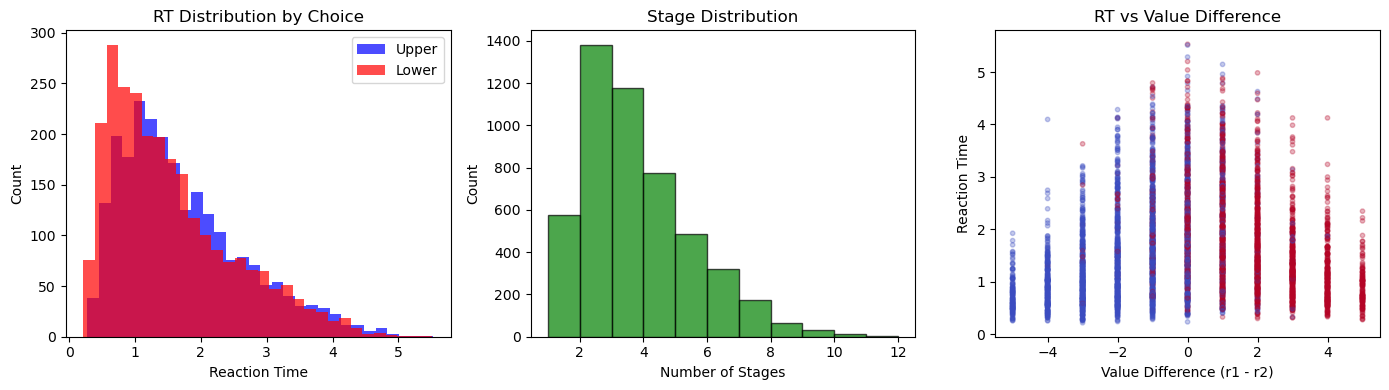

In [6]:
# Visualize data
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(rt_data[choice_data == 1], bins=30, alpha=0.7, label='Upper', color='blue')
axes[0].hist(rt_data[choice_data == -1], bins=30, alpha=0.7, label='Lower', color='red')
axes[0].set_xlabel('Reaction Time')
axes[0].set_ylabel('Count')
axes[0].set_title('RT Distribution by Choice')
axes[0].legend()

axes[1].hist(d_data, bins=range(1, max_d + 2), alpha=0.7, color='green', edgecolor='black')
axes[1].set_xlabel('Number of Stages')
axes[1].set_ylabel('Count')
axes[1].set_title('Stage Distribution')

axes[2].scatter(r1_data - r2_data, rt_data, alpha=0.3, s=10, c=choice_data, cmap='coolwarm')
axes[2].set_xlabel('Value Difference (r1 - r2)')
axes[2].set_ylabel('Reaction Time')
axes[2].set_title('RT vs Value Difference')

plt.tight_layout()
plt.show()


## 2. Define Likelihood Functions


In [7]:
# ============================================================
# CONFIGURATION: Which implementations to test
# ============================================================
RUN_CYTHON = True      # Cython + OpenMP (if available)
RUN_JAX_NOGRAD = True  # JAX without gradients
RUN_JAX_GRAD = True    # JAX with gradients

JAX_USE_REMAT = False           # relevant for gradient workloads
TRUNC_NUM_JAX = 5               # fixed JAX series truncation used for this demonstration
TRUNC_NUM_CYTHON = 100          # cython has adaptive stopping

In [8]:
# Try to import the public Cython package surface
CYTHON_AVAILABLE = False
if RUN_CYTHON:
    try:
        from efficient_fpt.cython import print_num_threads
        CYTHON_AVAILABLE = True
        print("Cython implementation available:")
        print_num_threads()
    except ImportError as e:
        print(f"Cython not available: {e}")
        print("(Run 'pip install -e .' to build Cython extensions)")


Cython implementation available:
Number of available threads: 64


In [9]:
# Public JAX batch APIs — both variants
from efficient_fpt.jax import (
    compute_addm_loglikelihoods_batchscan,
    compute_addm_loglikelihoods_batchvmap,
    make_addm_nll_function_batchscan,
    make_addm_nll_function_batchvmap,
)

jax_rt = jnp.array(rt_data)
jax_choice = jnp.array(choice_data)
jax_d = jnp.array(d_data)
jax_r1 = jnp.array(r1_data)
jax_r2 = jnp.array(r2_data)
jax_flag = jnp.array(flag_data)
jax_sacc = jnp.array(sacc_data_padded)

print(f"Using both JAX batch variants (use_remat={JAX_USE_REMAT}, trunc_num={TRUNC_NUM_JAX})")

Using both JAX batch variants (use_remat=False, trunc_num=5)


In [10]:
# Build NLL closures for both batch variants
common_kwargs = dict(
    rt_data=rt_data,
    choice_data=choice_data,
    r1_data=r1_data,
    r2_data=r2_data,
    flag_data=flag_data,
    sacc_array_data=sacc_data_padded,
    d_data=d_data,
    order_mid=30,
    order_last=30,
    trunc_num=TRUNC_NUM_JAX,
    use_remat=JAX_USE_REMAT,
)

jax_sum_nll_batchscan = make_addm_nll_function_batchscan(**common_kwargs)
jax_sum_nll_batchvmap = make_addm_nll_function_batchvmap(**common_kwargs)

def jax_mean_nll_batchscan(params):
    eta, kappa, a, b, x0 = params
    return jax_sum_nll_batchscan(eta, kappa, TRUE_PARAMS['sigma'], a, b, x0) / num_data

def jax_mean_nll_batchvmap(params):
    eta, kappa, a, b, x0 = params
    return jax_sum_nll_batchvmap(eta, kappa, TRUE_PARAMS['sigma'], a, b, x0) / num_data

print("Built JAX mean-NLL closures for both batchscan and batchvmap.")

Built JAX mean-NLL closures for both batchscan and batchvmap.


In [11]:
# JIT-compile both variants
jax_nll_batchscan = jit(jax_mean_nll_batchscan)
jax_nll_batchvmap = jit(jax_mean_nll_batchvmap)

test_params = jnp.array([0.7, 0.5, 2.1, 0.3, -0.2])

nll_scan = jax_nll_batchscan(test_params)
nll_vmap = jax_nll_batchvmap(test_params)
print(f"Test NLL at true params (batchscan): {float(nll_scan):.4f}")
print(f"Test NLL at true params (batchvmap): {float(nll_vmap):.4f}")

Test NLL at true params (batchscan): 1.3611
Test NLL at true params (batchvmap): 1.3611


In [12]:
# Gradients for both variants
jax_nll_grad_batchscan = jit(grad(jax_mean_nll_batchscan))
jax_nll_grad_batchvmap = jit(grad(jax_mean_nll_batchvmap))

grad_scan = jax_nll_grad_batchscan(test_params)
grad_vmap = jax_nll_grad_batchvmap(test_params)

print("Gradient at true params (batchscan):")
for name, val in zip(['eta', 'kappa', 'a', 'b', 'x0'], grad_scan):
    print(f"  d/d{name} = {float(val):.6f}")
print()
print("Gradient at true params (batchvmap):")
for name, val in zip(['eta', 'kappa', 'a', 'b', 'x0'], grad_vmap):
    print(f"  d/d{name} = {float(val):.6f}")

Gradient at true params (batchscan):
  d/deta = 0.002027
  d/dkappa = -0.010562
  d/da = 0.017472
  d/db = -0.046169
  d/dx0 = -0.006052

Gradient at true params (batchvmap):
  d/deta = 0.002027
  d/dkappa = -0.010562
  d/da = 0.017472
  d/db = -0.046169
  d/dx0 = -0.006052


In [13]:
# ============================================================
# DIAGNOSTIC: Verify log-likelihood computation across all trials
# ============================================================

def get_trial_loglikelihoods(params, loglik_fn):
    """Get the per-trial log-likelihoods from a batch API function."""
    eta, kappa, a, b, x0 = params
    return loglik_fn(
        jax_rt, jax_choice, eta, kappa, TRUE_PARAMS['sigma'], a, b, x0,
        jax_r1, jax_r2, jax_flag, jax_sacc, jax_d,
        order_mid=30, order_last=30,
        trunc_num=TRUNC_NUM_JAX, use_remat=JAX_USE_REMAT,
    )

true_params_list = [
    TRUE_PARAMS['eta'], TRUE_PARAMS['kappa'],
    TRUE_PARAMS['a'], TRUE_PARAMS['b'], TRUE_PARAMS['x0'],
]

for name, fn in [("batchscan", compute_addm_loglikelihoods_batchscan),
                 ("batchvmap", compute_addm_loglikelihoods_batchvmap)]:
    trial_ll = get_trial_loglikelihoods(true_params_list, fn)
    n_finite = int(jnp.sum(jnp.isfinite(trial_ll)))
    print(f"=== {name} ===")
    print(f"  Trials: {len(trial_ll)}, Finite: {n_finite}/{len(trial_ll)}")
    print(f"  Min: {float(jnp.min(trial_ll)):.4f}, Max: {float(jnp.max(trial_ll)):.4f}, "
          f"Mean: {float(jnp.mean(trial_ll)):.4f}")
    print()

=== batchscan ===
  Trials: 5000, Finite: 5000/5000
  Min: -7.9332, Max: 0.5817, Mean: -1.3611

=== batchvmap ===
  Trials: 5000, Finite: 5000/5000
  Min: -7.9332, Max: 0.5817, Mean: -1.3611



In [14]:
# Cython NLL wrapper through the public model method
if CYTHON_AVAILABLE:
    def cython_nll(params, *, log_space=False, warn=True):
        eta, kappa, a, b, x0 = params
        cy_model = aDDModel(
            eta=eta,
            kappa=kappa,
            sigma=TRUE_PARAMS['sigma'],
            a=a,
            b=b,
            x0=x0,
        )
        return cy_model.mean_neg_log_likelihood(
            rt_data,
            choice_data,
            r1_data,
            r2_data,
            flag_data,
            sacc_data_padded,
            d_data,
            order_mid=30,
            order_last=30,
            trunc_num=TRUNC_NUM_CYTHON,
            log_space=log_space,
            warn=warn,
        )

    test_cython_nll = cython_nll([0.7, 0.5, 2.1, 0.3, -0.2])
    print(f"Cython NLL at true params: {test_cython_nll:.4f}")


Cython NLL at true params: 1.3611


## 3. Likelihood Evaluation Timing


In [15]:
print("=" * 60)
print("LIKELIHOOD EVALUATION TIMING")
print("=" * 60)

n_evals = 20
results = {}

if CYTHON_AVAILABLE:
    _ = cython_nll([0.7, 0.5, 2.1, 0.3, -0.2])
    start = time.time()
    for _ in range(n_evals):
        _ = cython_nll([0.7, 0.5, 2.1, 0.3, -0.2])
    cython_time = (time.time() - start) / n_evals * 1000
    results['Cython'] = cython_time
    print(f"Cython (public model API): {cython_time:.2f} ms/eval")

for variant_name, nll_fn, grad_fn in [
    ("batchscan", jax_nll_batchscan, jax_nll_grad_batchscan),
    ("batchvmap", jax_nll_batchvmap, jax_nll_grad_batchvmap),
]:
    if RUN_JAX_NOGRAD:
        _ = nll_fn(test_params).block_until_ready()
        start = time.time()
        for _ in range(n_evals):
            _ = nll_fn(test_params).block_until_ready()
        jax_time = (time.time() - start) / n_evals * 1000
        results[f'JAX ({variant_name})'] = jax_time
        print(f"JAX ({variant_name}):      {jax_time:.2f} ms/eval")

    if RUN_JAX_GRAD:
        _ = grad_fn(test_params).block_until_ready()
        start = time.time()
        for _ in range(n_evals):
            _ = grad_fn(test_params).block_until_ready()
        jax_grad_time = (time.time() - start) / n_evals * 1000
        results[f'JAX ({variant_name})+grad'] = jax_grad_time
        print(f"JAX ({variant_name})+grad: {jax_grad_time:.2f} ms/eval")

print()

LIKELIHOOD EVALUATION TIMING
Cython (public model API): 784.21 ms/eval
JAX (batchscan):      84.84 ms/eval
JAX (batchscan)+grad: 316.45 ms/eval
JAX (batchvmap):      83.20 ms/eval
JAX (batchvmap)+grad: 204.51 ms/eval



## 4. Maximum Likelihood Estimation


In [16]:
# Match the constrained MLE setup used in example4_new/addm_inference.ipynb
max_rt = np.max(rt_data)
bounds = Bounds(
    [0, 0, 0, 0, -np.inf],
    [1, np.inf, np.inf, np.inf, np.inf],
    keep_feasible=True,
)
constraints = LinearConstraint(
    [[0, 0, 1, -max_rt, 0], [0, 0, 1, 0, 1], [0, 0, 1, 0, -1]],
    lb=[0, 0, 0],
    ub=[np.inf, np.inf, np.inf],
    keep_feasible=True,
)

# Same initial guess as the reference constrained-MLE notebook
initial_guess = [0.5, 1.0, 1.0, 0.1, 0.0]

print(
    f"Initial guess: eta={initial_guess[0]}, kappa={initial_guess[1]}, "
    f"a={initial_guess[2]}, b={initial_guess[3]}, x0={initial_guess[4]}"
)
print(
    f"True values:   eta={TRUE_PARAMS['eta']}, kappa={TRUE_PARAMS['kappa']}, "
    f"a={TRUE_PARAMS['a']}, b={TRUE_PARAMS['b']}, x0={TRUE_PARAMS['x0']}"
)
print("Using the same linear constraints as example4_new/addm_inference.ipynb:")
print("  1. a - b * max(rt) >= 0")
print("  2. a + x0 >= 0")
print("  3. a - x0 >= 0")
print("Bounds and linear constraints are marked keep_feasible=True.")

optimization_results = {}


Initial guess: eta=0.5, kappa=1.0, a=1.0, b=0.1, x0=0.0
True values:   eta=0.7, kappa=0.5, a=2.1, b=0.3, x0=-0.2
Using the same linear constraints as example4_new/addm_inference.ipynb:
  1. a - b * max(rt) >= 0
  2. a + x0 >= 0
  3. a - x0 >= 0
Bounds and linear constraints are marked keep_feasible=True.


### 4.1 Cython Optimization (trust-constr, Same Constraints)


In [17]:
if CYTHON_AVAILABLE and RUN_CYTHON:
    print("=" * 60)
    print("CYTHON OPTIMIZATION (trust-constr, constrained MLE)")
    print("=" * 60)

    n_feval = [0]

    def cython_obj(params):
        n_feval[0] += 1
        return cython_nll(params)

    start = time.time()
    result_cython = minimize(
        cython_obj,
        x0=initial_guess,
        method='trust-constr',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 500},
    )
    cython_opt_time = time.time() - start

    optimization_results['Cython (trust-constr)'] = {
        'time': cython_opt_time,
        'params': result_cython.x,
        'nll': result_cython.fun,
        'nfev': n_feval[0],
        'success': result_cython.success,
    }

    print(f"Time: {cython_opt_time:.1f}s")
    print(f"Function evaluations: {n_feval[0]}")
    print(f"Final NLL: {result_cython.fun:.4f}")
    print("Estimated parameters:")
    print(f"  eta:   {result_cython.x[0]:.4f} (true: {TRUE_PARAMS['eta']})")
    print(f"  kappa: {result_cython.x[1]:.4f} (true: {TRUE_PARAMS['kappa']})")
    print(f"  a:     {result_cython.x[2]:.4f} (true: {TRUE_PARAMS['a']})")
    print(f"  b:     {result_cython.x[3]:.4f} (true: {TRUE_PARAMS['b']})")
    print(f"  x0:    {result_cython.x[4]:.4f} (true: {TRUE_PARAMS['x0']})")


CYTHON OPTIMIZATION (trust-constr, constrained MLE)
Time: 361.7s
Function evaluations: 456
Final NLL: 1.3610
Estimated parameters:
  eta:   0.6987 (true: 0.7)
  kappa: 0.4999 (true: 0.5)
  a:     2.0973 (true: 2.1)
  b:     0.3036 (true: 0.3)
  x0:    -0.1940 (true: -0.2)


### 4.2 JAX Optimization (trust-constr, No Autodiff) — batchscan vs batchvmap

In [18]:
if RUN_JAX_NOGRAD:
    for variant_name, nll_fn in [
        ("batchscan", jax_nll_batchscan),
        ("batchvmap", jax_nll_batchvmap),
    ]:
        print("=" * 60)
        print(f"JAX OPTIMIZATION ({variant_name}, trust-constr, no autodiff)")
        print("=" * 60)

        n_feval = [0]

        def jax_obj_nograd(params, _nll_fn=nll_fn):
            n_feval[0] += 1
            return float(_nll_fn(jnp.array(params)))

        start = time.time()
        result = minimize(
            jax_obj_nograd,
            x0=initial_guess,
            method='trust-constr',
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': 500},
        )
        opt_time = time.time() - start

        label = f'JAX {variant_name} (no grad)'
        optimization_results[label] = {
            'time': opt_time,
            'params': result.x,
            'nll': result.fun,
            'nfev': n_feval[0],
            'success': result.success,
        }

        print(f"Time: {opt_time:.1f}s, f-evals: {n_feval[0]}, NLL: {result.fun:.4f}")
        for pname, pval, ptrue in zip(
            ['eta', 'kappa', 'a', 'b', 'x0'], result.x,
            [TRUE_PARAMS[k] for k in ['eta', 'kappa', 'a', 'b', 'x0']],
        ):
            print(f"  {pname}: {pval:.4f} (true: {ptrue})")
        print()

JAX OPTIMIZATION (batchscan, trust-constr, no autodiff)
Time: 15.9s, f-evals: 186, NLL: 1.3610
  eta: 0.6987 (true: 0.7)
  kappa: 0.4999 (true: 0.5)
  a: 2.0973 (true: 2.1)
  b: 0.3036 (true: 0.3)
  x0: -0.1940 (true: -0.2)

JAX OPTIMIZATION (batchvmap, trust-constr, no autodiff)
Time: 15.8s, f-evals: 186, NLL: 1.3610
  eta: 0.6987 (true: 0.7)
  kappa: 0.4999 (true: 0.5)
  a: 2.0973 (true: 2.1)
  b: 0.3036 (true: 0.3)
  x0: -0.1940 (true: -0.2)



### 4.3 JAX Optimization (trust-constr, Autodiff) — batchscan vs batchvmap

In [19]:
if RUN_JAX_GRAD:
    for variant_name, nll_fn, grad_fn in [
        ("batchscan", jax_nll_batchscan, jax_nll_grad_batchscan),
        ("batchvmap", jax_nll_batchvmap, jax_nll_grad_batchvmap),
    ]:
        print("=" * 60)
        print(f"JAX OPTIMIZATION ({variant_name}, trust-constr, autodiff)")
        print("=" * 60)

        n_feval = [0]
        n_geval = [0]

        def jax_obj(params, _nll_fn=nll_fn):
            n_feval[0] += 1
            return float(_nll_fn(jnp.array(params)))

        def jax_gradient(params, _grad_fn=grad_fn):
            n_geval[0] += 1
            return np.array(_grad_fn(jnp.array(params)))

        start = time.time()
        result = minimize(
            jax_obj,
            x0=initial_guess,
            method='trust-constr',
            jac=jax_gradient,
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': 500},
        )
        opt_time = time.time() - start

        label = f'JAX {variant_name} (grad)'
        optimization_results[label] = {
            'time': opt_time,
            'params': result.x,
            'nll': result.fun,
            'nfev': n_feval[0],
            'ngev': n_geval[0],
            'success': result.success,
        }

        print(f"Time: {opt_time:.1f}s, f-evals: {n_feval[0]}, g-evals: {n_geval[0]}, NLL: {result.fun:.4f}")
        for pname, pval, ptrue in zip(
            ['eta', 'kappa', 'a', 'b', 'x0'], result.x,
            [TRUE_PARAMS[k] for k in ['eta', 'kappa', 'a', 'b', 'x0']],
        ):
            print(f"  {pname}: {pval:.4f} (true: {ptrue})")
        print()

JAX OPTIMIZATION (batchscan, trust-constr, autodiff)
Time: 12.1s, f-evals: 30, g-evals: 30, NLL: 1.3610
  eta: 0.6987 (true: 0.7)
  kappa: 0.4999 (true: 0.5)
  a: 2.0973 (true: 2.1)
  b: 0.3036 (true: 0.3)
  x0: -0.1940 (true: -0.2)

JAX OPTIMIZATION (batchvmap, trust-constr, autodiff)
Time: 8.8s, f-evals: 30, g-evals: 30, NLL: 1.3610
  eta: 0.6987 (true: 0.7)
  kappa: 0.4999 (true: 0.5)
  a: 2.0973 (true: 2.1)
  b: 0.3036 (true: 0.3)
  x0: -0.1940 (true: -0.2)



## 5. Results Summary


In [20]:
print("=" * 70)
print("OPTIMIZATION RESULTS SUMMARY")
print("=" * 70)
print()

print(f"{'Method':<30} {'Time (s)':<12} {'NLL':<12} {'f evals':<10} {'g evals':<10}")
print("-" * 70)

for name, res in optimization_results.items():
    ngev = res.get('ngev', '-')
    print(f"{name:<30} {res['time']:<12.1f} {res['nll']:<12.4f} {res['nfev']:<10} {ngev:<10}")

print()
print("Parameter Estimates:")
print(f"{'Method':<30} {'eta':<10} {'kappa':<10} {'a':<10} {'b':<10} {'x0':<10}")
print("-" * 70)
print(f"{'TRUE':<30} {TRUE_PARAMS['eta']:<10.4f} {TRUE_PARAMS['kappa']:<10.4f} {TRUE_PARAMS['a']:<10.4f} {TRUE_PARAMS['b']:<10.4f} {TRUE_PARAMS['x0']:<10.4f}")

for name, res in optimization_results.items():
    p = res['params']
    print(f"{name:<30} {p[0]:<10.4f} {p[1]:<10.4f} {p[2]:<10.4f} {p[3]:<10.4f} {p[4]:<10.4f}")


OPTIMIZATION RESULTS SUMMARY

Method                         Time (s)     NLL          f evals    g evals   
----------------------------------------------------------------------
Cython (trust-constr)          361.7        1.3610       456        -         
JAX batchscan (no grad)        15.9         1.3610       186        -         
JAX batchvmap (no grad)        15.8         1.3610       186        -         
JAX batchscan (grad)           12.1         1.3610       30         30        
JAX batchvmap (grad)           8.8          1.3610       30         30        

Parameter Estimates:
Method                         eta        kappa      a          b          x0        
----------------------------------------------------------------------
TRUE                           0.7000     0.5000     2.1000     0.3000     -0.2000   
Cython (trust-constr)          0.6987     0.4999     2.0973     0.3036     -0.1940   
JAX batchscan (no grad)        0.6987     0.4999     2.0973     0.3036    

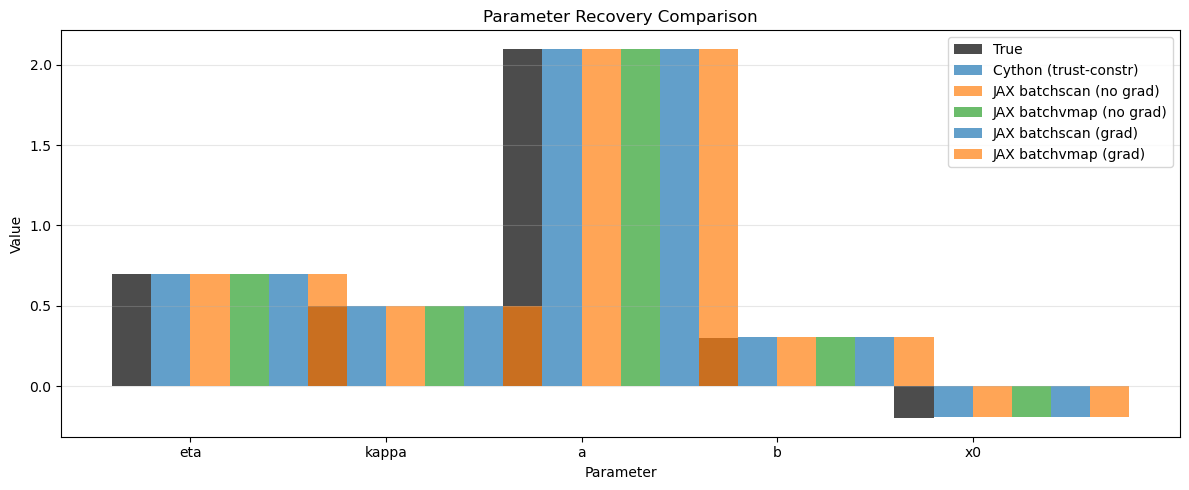

In [21]:
# Visualize parameter recovery
param_names = ['eta', 'kappa', 'a', 'b', 'x0']
true_values = [TRUE_PARAMS[p] for p in param_names]

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(param_names))
width = 0.2

# Plot true values
ax.bar(x - width * 1.5, true_values, width, label='True', color='black', alpha=0.7)

# Plot estimated values
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, (name, res) in enumerate(optimization_results.items()):
    ax.bar(x - width * 0.5 + i * width, res['params'], width, label=name, color=colors[i % len(colors)], alpha=0.7)

ax.set_xlabel('Parameter')
ax.set_ylabel('Value')
ax.set_title('Parameter Recovery Comparison')
ax.set_xticks(x)
ax.set_xticklabels(param_names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


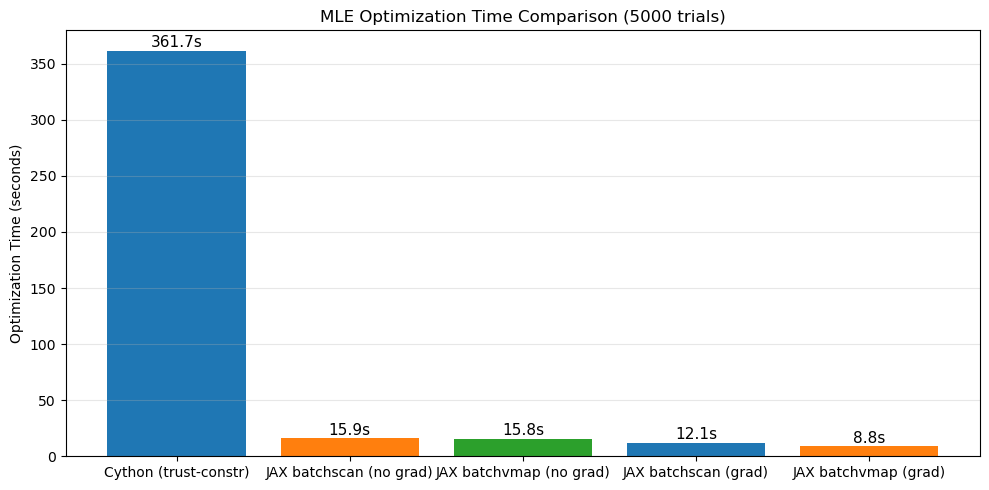

In [22]:
# Timing comparison bar chart
if len(optimization_results) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    names = list(optimization_results.keys())
    times = [optimization_results[n]['time'] for n in names]
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    bars = ax.bar(names, times, color=colors[:len(names)])
    
    ax.set_ylabel('Optimization Time (seconds)')
    ax.set_title(f'MLE Optimization Time Comparison ({NUM_TRIALS} trials)')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add time labels on bars
    for bar, t in zip(bars, times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{t:.1f}s', ha='center', va='bottom', fontsize=11)
    
    plt.tight_layout()
    plt.show()


## 5.1 Likelihood Landscape Analysis

Understanding parameter identifiability by examining the likelihood profile around the optimum. 

**Interpretation:**
- **High curvature** = Well-identified parameter (small changes in parameter → large changes in NLL)
- **Low curvature** = Poorly identified / flat landscape (harder to optimize)
- **Green line** = Estimated value
- **Red line** = True value


In [23]:
optimization_results

{'Cython (trust-constr)': {'time': 361.7051303386688,
  'params': array([ 0.69866865,  0.49985788,  2.09730082,  0.3036325 , -0.19402099]),
  'nll': 1.360975215835988,
  'nfev': 456,
  'success': True},
 'JAX batchscan (no grad)': {'time': 15.8690767288208,
  'params': array([ 0.69866878,  0.49985782,  2.09730075,  0.30363251, -0.19402088]),
  'nll': 1.3609752158359574,
  'nfev': 186,
  'success': True},
 'JAX batchvmap (no grad)': {'time': 15.790629863739014,
  'params': array([ 0.69866878,  0.49985782,  2.09730075,  0.30363251, -0.19402088]),
  'nll': 1.3609752158359574,
  'nfev': 186,
  'success': True},
 'JAX batchscan (grad)': {'time': 12.146825790405273,
  'params': array([ 0.69866882,  0.49985788,  2.09730082,  0.30363245, -0.19402093]),
  'nll': 1.3609752158360084,
  'nfev': 30,
  'ngev': 30,
  'success': True},
 'JAX batchvmap (grad)': {'time': 8.800981521606445,
  'params': array([ 0.69866882,  0.49985788,  2.09730082,  0.30363245, -0.19402093]),
  'nll': 1.3609752158360084,


Analyzing likelihood landscape around JAX batchscan (grad) optimum...
Best NLL: 1.3610



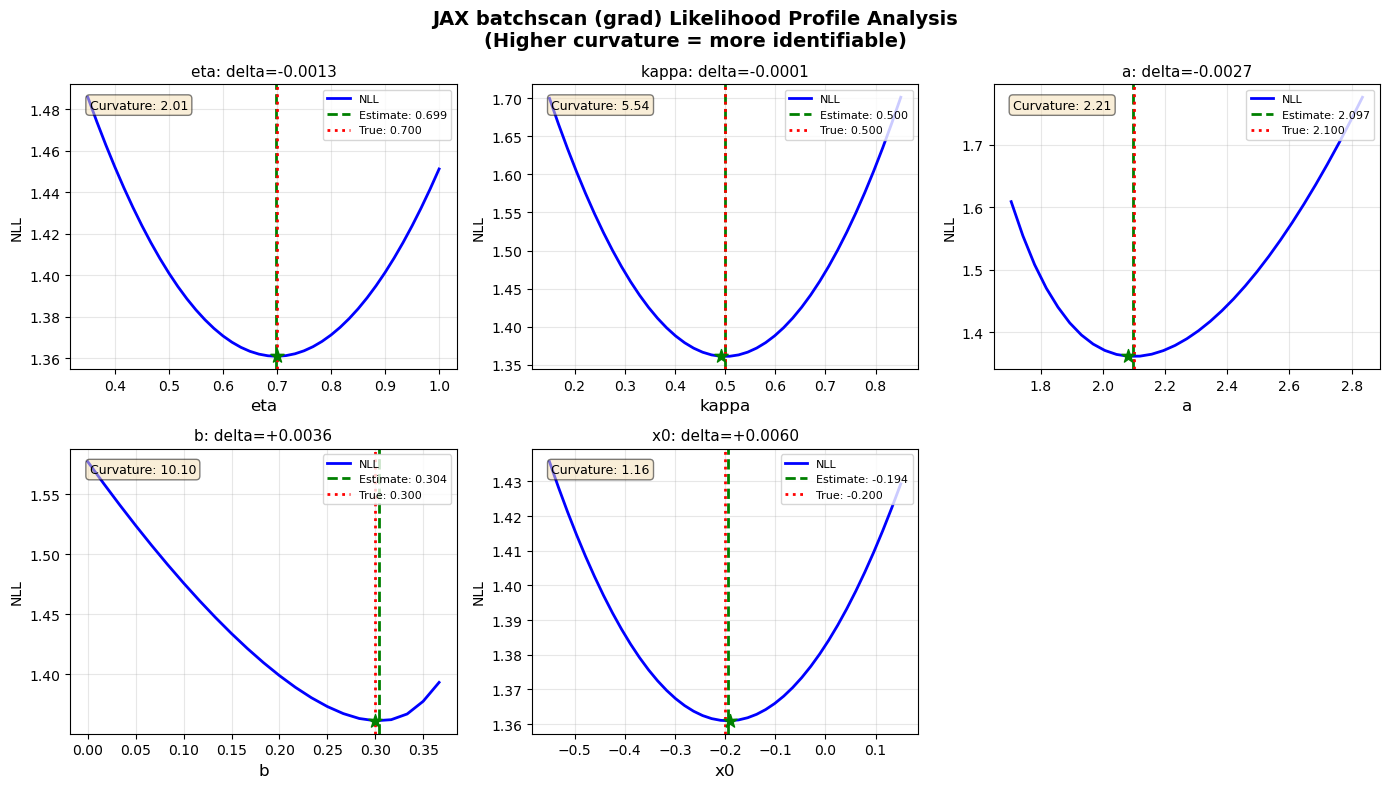

In [24]:
# ============================================================
# LIKELIHOOD LANDSCAPE ANALYSIS
# ============================================================
# Plot profile likelihoods to understand parameter sensitivity

def is_feasible_profile_point(params, bounds, max_rt):
    eta, kappa, a, b, x0 = [float(v) for v in params]
    lower = np.asarray(bounds.lb, dtype=np.float64)
    upper = np.asarray(bounds.ub, dtype=np.float64)
    point = np.asarray([eta, kappa, a, b, x0], dtype=np.float64)

    finite_lower = np.isfinite(lower)
    finite_upper = np.isfinite(upper)
    if np.any(point[finite_lower] < lower[finite_lower]):
        return False
    if np.any(point[finite_upper] > upper[finite_upper]):
        return False

    return (a - b * max_rt >= 0) and (a + x0 >= 0) and (a - x0 >= 0)


def plot_likelihood_profiles(best_params, param_names, true_params, nll_func,
                             bounds, max_rt, n_points=50, title_prefix=""):
    """
    Plot 1D likelihood profiles for each parameter.

    For each parameter, vary it within a finite local window around the true
    value, while holding the other parameters fixed at the selected optimum.
    Infeasible points are skipped.
    """
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for i, (name, ax) in enumerate(zip(param_names, axes)):
        if i >= len(param_names):
            ax.set_visible(False)
            continue

        opt_val = best_params[i]
        true_val = true_params[name]

        radius = max(0.2, 0.35 * max(abs(true_val), abs(opt_val), 1.0))
        lo = true_val - radius
        hi = true_val + radius

        if np.isfinite(bounds.lb[i]):
            lo = max(lo, bounds.lb[i])
        if np.isfinite(bounds.ub[i]):
            hi = min(hi, bounds.ub[i])

        param_grid = np.linspace(lo, hi, n_points)
        nll_values = np.full(n_points, np.nan)

        for j, val in enumerate(param_grid):
            test_params = best_params.copy()
            test_params[i] = val
            if not is_feasible_profile_point(test_params, bounds, max_rt):
                continue
            nll_values[j] = nll_func(test_params)

        feasible = np.isfinite(nll_values)
        if not np.any(feasible):
            ax.set_title(f'{name}: no feasible points in local window', fontsize=11)
            ax.set_xlabel(name, fontsize=12)
            ax.set_ylabel('NLL', fontsize=10)
            ax.grid(True, alpha=0.3)
            continue

        ax.plot(param_grid[feasible], nll_values[feasible], 'b-', linewidth=2, label='NLL')
        ax.axvline(opt_val, color='green', linestyle='--', linewidth=2,
                   label=f'Estimate: {opt_val:.3f}')
        ax.axvline(true_val, color='red', linestyle=':', linewidth=2,
                   label=f'True: {true_val:.3f}')

        feasible_idx = np.where(feasible)[0]
        min_local_idx = feasible_idx[np.argmin(nll_values[feasible])]
        ax.scatter([param_grid[min_local_idx]], [nll_values[min_local_idx]],
                   color='green', s=100, zorder=5, marker='*')

        ax.set_xlabel(name, fontsize=12)
        ax.set_ylabel('NLL', fontsize=10)
        ax.set_title(f'{name}: delta={opt_val - true_val:+.4f}', fontsize=11)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3)

        if np.sum(feasible) > 2:
            idx_opt = np.argmin(np.abs(param_grid - opt_val))
            if 0 < idx_opt < len(nll_values) - 1 and np.all(np.isfinite(nll_values[idx_opt-1:idx_opt+2])):
                h = param_grid[1] - param_grid[0]
                curvature = (nll_values[idx_opt+1] - 2*nll_values[idx_opt] + nll_values[idx_opt-1]) / h**2
                ax.text(0.05, 0.95, f'Curvature: {curvature:.2f}',
                        transform=ax.transAxes, fontsize=9, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    if len(param_names) < 6:
        axes[5].set_visible(False)

    fig.suptitle(f"{title_prefix}Likelihood Profile Analysis\n(Higher curvature = more identifiable)",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return fig


# Use the batchscan grad result for landscape analysis (arbitrary choice)
best_key = 'JAX batchscan (grad)'
if best_key not in optimization_results:
    # Fallback: pick the first available JAX grad result
    best_key = next((k for k in optimization_results if 'grad' in k and 'no grad' not in k), None)
if best_key is None:
    best_key = next(iter(optimization_results))

best_result = optimization_results[best_key]
print(f"Analyzing likelihood landscape around {best_key} optimum...")
print(f"Best NLL: {best_result['nll']:.4f}")
print()

# Build a profile NLL using batchscan
profile_nll_fn = make_addm_nll_function_batchscan(
    rt_data, choice_data, r1_data, r2_data, flag_data,
    sacc_data_padded, d_data,
    order_mid=30, order_last=30,
    trunc_num=TRUNC_NUM_JAX, log_space=True, use_remat=JAX_USE_REMAT,
)

def profile_nll(params):
    eta, kappa, a, b, x0 = params
    return float(profile_nll_fn(eta, kappa, TRUE_PARAMS['sigma'], a, b, x0) / num_data)

param_names = ['eta', 'kappa', 'a', 'b', 'x0']
true_params_dict = {name: TRUE_PARAMS[name] for name in param_names}

_ = plot_likelihood_profiles(
    best_params=best_result['params'],
    param_names=param_names,
    true_params=true_params_dict,
    nll_func=profile_nll,
    bounds=bounds,
    max_rt=max_rt,
    n_points=40,
    title_prefix=f"{best_key} ",
)

## 6. Key Takeaways

### Performance
- This notebook compares all solvers under the **same constrained MLE formulation** used in `example4_new/addm_inference.ipynb`.
- Both JAX batch variants (**batchscan** and **batchvmap**) are compared head-to-head for likelihood evaluation speed, gradient speed, and optimizer convergence.
- **batchscan** uses `jax.lax.scan` to iterate over trials sequentially (lower memory, works with remat).
- **batchvmap** uses `jax.vmap` to vectorize over trials in parallel (potentially faster on GPU, higher memory).

### Accuracy
- Because the bounds and linear constraints match the reference MLE notebook, differences across methods are interpretable.
- Any remaining discrepancy is less likely to come from one method wandering into an infeasible region.

### When to Use What
| Scenario | Recommendation |
|----------|----------------|
| Reference constrained MLE on CPU | Cython + `trust-constr` |
| GPU with large trial counts | JAX batchvmap + autodiff |
| GPU with memory constraints | JAX batchscan + autodiff (+ `use_remat`) |
| Bayesian inference / HMC / NUTS | JAX (either variant) |